## Supplier Billing Spike and Drop Analysis

### Research Question
Which Missouri suppliers show abnormal billing spikes followed by a complete drop in services the following year?

### Fraud Signal
A common fraud signal is when a supplier rapidly increases billing volume and then disappears from the dataset the following year.

To detect this pattern, we compute:

- Growth from 2021 to 2022
- Drop from 2022 to 2023

We then filter suppliers where:

2021 services = 0 and
2023 services = 0

This highlights suppliers that may have exploited billing opportunities temporarily before stopping activity.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/dsa/groups/casestudycf25/team02/silver/dmepos_suplr_serv_clean.csv")

# Missouri suppliers
df_mo = df[df["suplr_prvdr_state_abrvtn"] == "MO"]

# Aggregate services
supplier_year = (
    df_mo
    .groupby(["suplr_npi","year"])["tot_suplr_srvcs"]
    .sum()
    .reset_index()
)

# Pivot
pivot = supplier_year.pivot(index="suplr_npi", columns="year", values="tot_suplr_srvcs").fillna(0)

pivot.head()

year,2021,2022,2023
suplr_npi,,,
1003045436,3561.0,3682.0,4197.0
1003230335,5980.0,6962.0,4212.0
1003268087,93.0,70.0,71.0
1003281619,4957.0,5112.0,1639.0
1003282138,68.0,95.0,87.0


In [2]:
pivot["Total"] = pivot[2021] + pivot[2022] + pivot[2023]
pivot.head()

year,2021,2022,2023,Total
suplr_npi,,,,
1003045436,3561.0,3682.0,4197.0,11440.0
1003230335,5980.0,6962.0,4212.0,17154.0
1003268087,93.0,70.0,71.0,234.0
1003281619,4957.0,5112.0,1639.0,11708.0
1003282138,68.0,95.0,87.0,250.0


In [3]:
fraud_pattern = pivot[
    (pivot[2021] == 0) &
    (pivot[2023] == 0) 
]
print(fraud_pattern.shape)
fraud_pattern.head()

(20, 4)


year,2021,2022,2023,Total
suplr_npi,,,,
1083206486,0.0,22.0,0.0,22.0
1194116061,0.0,13.0,0.0,13.0
1215504394,0.0,103.0,0.0,103.0
1235732603,0.0,11.0,0.0,11.0
1306918305,0.0,38.0,0.0,38.0


In [4]:
# Create an explicit copy to break the link to the original slice
fraud_pattern = fraud_pattern.copy()


fraud_pattern["growth_21_22"] = fraud_pattern[2022] - fraud_pattern[2021] 
fraud_pattern["drop_22_23"] = fraud_pattern[2022] - fraud_pattern[2023]


fraud_pattern.head()

year,2021,2022,2023,Total,growth_21_22,drop_22_23
suplr_npi,,,,,,
1083206486,0.0,22.0,0.0,22.0,22.0,22.0
1194116061,0.0,13.0,0.0,13.0,13.0,13.0
1215504394,0.0,103.0,0.0,103.0,103.0,103.0
1235732603,0.0,11.0,0.0,11.0,11.0,11.0
1306918305,0.0,38.0,0.0,38.0,38.0,38.0


In [5]:
#We need to store the sum of all supplier spend and also the count of the number of surges suppliers
sup_count = pd.DataFrame({
    'Total_Spend': [pivot["Total"].sum()],
    'Surge_Supplier_Count': [fraud_pattern.shape[0]]
})

In [6]:
sup_count

,Total_Spend,Surge_Supplier_Count
0,343426612.0,20


In [7]:
sup_count.to_csv("surges_count.csv")
print("Saved: surges_count.csv")

Saved: surges_count.csv


In [8]:
fraud_pattern = fraud_pattern.sort_values(
    "growth_21_22", ascending=False
)
all_pattern = fraud_pattern
fraud_pattern = fraud_pattern.head()

In [9]:
plot_df = fraud_pattern.reset_index()[
    ["suplr_npi","growth_21_22","drop_22_23"]
]

plot_df

year,suplr_npi,growth_21_22,drop_22_23
0,1477999555,1244.0,1244.0
1,1487246898,1013.0,1013.0
2,1215504394,103.0,103.0
3,1568465359,85.0,85.0
4,1760558019,61.0,61.0


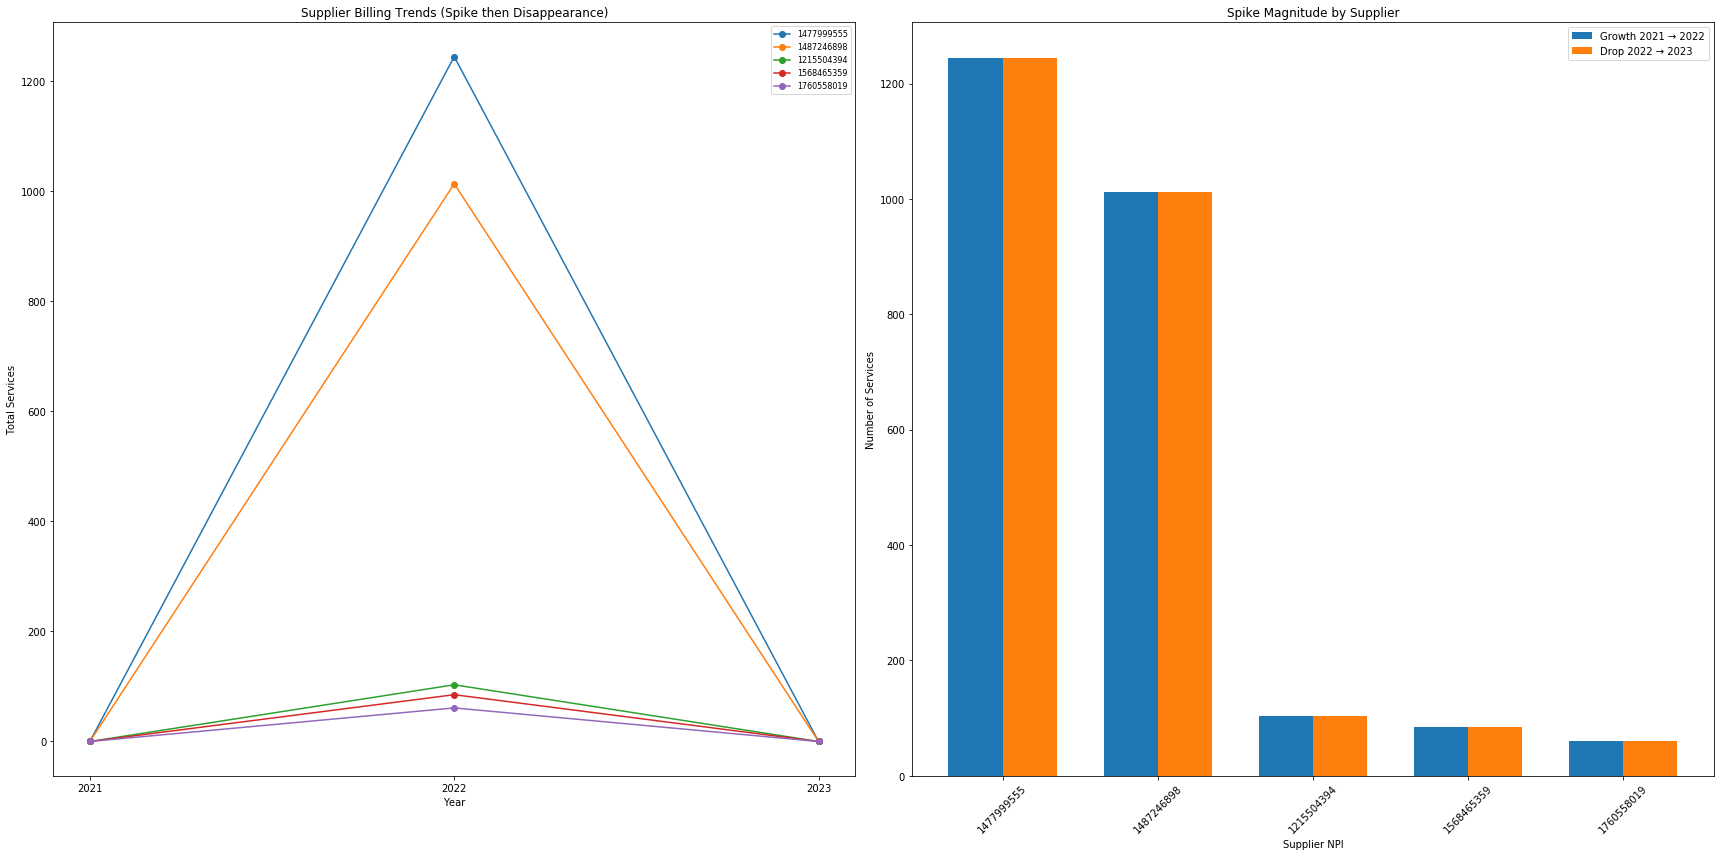

In [10]:
# Top suppliers used in the visualization
top_suppliers = fraud_pattern.head()

# NPIs for the line plot
top_npis = top_suppliers.index.tolist()

# Convert pivot table back to long format for line plot
trend_df = pivot.loc[top_npis].reset_index().melt(
    id_vars="suplr_npi",
    value_vars=[2021, 2022, 2023],
    var_name="year",
    value_name="tot_suplr_srvcs"
)

fig, axes = plt.subplots(1, 2, figsize=(24, 12))

# -------------------------
# LINE PLOT (Supplier Trend)
# -------------------------
for npi in top_npis:

    data = trend_df[trend_df["suplr_npi"] == npi]

    axes[0].plot(
        data["year"],
        data["tot_suplr_srvcs"],
        marker="o",
        label=str(npi)
    )

axes[0].set_xticks([2021, 2022, 2023])
axes[0].set_title("Supplier Billing Trends (Spike then Disappearance)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Total Services")
axes[0].legend(fontsize=8)


# -------------------------
# BAR PLOT (Spike Magnitude)
# -------------------------
plot_df = top_suppliers.reset_index()

x = np.arange(len(plot_df))
width = 0.35

axes[1].bar(
    x - width/2,
    plot_df["growth_21_22"],
    width,
    label="Growth 2021 → 2022"
)

axes[1].bar(
    x + width/2,
    plot_df["drop_22_23"],
    width,
    label="Drop 2022 → 2023"
)

axes[1].set_xticks(x)
axes[1].set_xticklabels(plot_df["suplr_npi"], rotation=45)

axes[1].set_title("Spike Magnitude by Supplier")
axes[1].set_xlabel("Supplier NPI")
axes[1].set_ylabel("Number of Services")

axes[1].legend()

plt.tight_layout()
plt.show()

### Insight

Based on this top 5 supplier NPI that supplied no equipment(s) in 2021, and then supplied in 2022 and disappear in 2023. It is worth flagging but does not alone confirm fraud. 

Such billing spikes represent interpretable signals that investigators can monitor through the dashboard.

Below, I am going to connect those suppliers to see which HCPCS codes that most supply, and flag those.

### HCPCS Code Concentration Analysis

After identifying suppliers with a spike-and-disappearance pattern, we examine
which HCPCS codes they billed during the spike year (2022).

This helps determine whether the flagged suppliers concentrate their activity
around a small number of service codes.

If multiple flagged suppliers are billing the same HCPCS code, that code may
represent a higher fraud risk and should be monitored more closely.

In [11]:
flagged_npis = top_suppliers.index.tolist()

print(flagged_npis)

[1477999555, 1487246898, 1215504394, 1568465359, 1760558019]


In [12]:
spike_df = df_mo[
    (df_mo["suplr_npi"].isin(flagged_npis)) &
    (df_mo["year"] == 2022)
]

In [13]:
# Set max colwidth to -1 to show the full description
pd.set_option('display.max_colwidth', -1)

hcpcs_usage = (
    spike_df
    .groupby(["hcpcs_cd", "hcpcs_desc"])["tot_suplr_srvcs"]
    .sum()
    .reset_index()
    .sort_values("tot_suplr_srvcs", ascending=False)
)

hcpcs_usage

,hcpcs_cd,hcpcs_desc,tot_suplr_srvcs
2,J7620,"Albuterol, up to 2.5 mg and ipratropium bromide, up to 0.5 mg, fda-approved final product, non-compounded, administered through dme",1230
1,J7507,"Tacrolimus, immediate release, oral, 1 mg",990
6,L2397,"Addition to lower extremity orthosis, suspension sleeve",41
10,V2203,"Spherocylinder, bifocal, plano to plus or minus 4.00d sphere, .12 to 2.00d cylinder, per lens",41
8,V2020,"Frames, purchases",37
9,V2200,"Sphere, bifocal, plano to plus or minus 4.00d, per lens",35
11,V2750,"Anti-reflective coating, per lens",33
3,L1832,"Knee orthosis, adjustable knee joints (unicentric or polycentric), positional orthosis, rigid support, prefabricated item that has been trimmed, bent, molded, assembled, or otherwise customized to fit a specific patient by an individual with expertise",25
0,A4253,"Blood glucose test or reagent strips for home blood glucose monitor, per 50 strips",23
4,L1833,"Knee orthosis, adjustable knee joints (unicentric or polycentric), positional orthosis, rigid support, prefabricated, off-the shelf",23


Which codes these suspicious suppliers used the most

In [14]:
supplier_hcpcs = (
    spike_df
    .groupby(["suplr_npi", "suplr_prvdr_last_name_org","hcpcs_cd", "hcpcs_desc"])["tot_suplr_srvcs"]
    .sum()
    .reset_index()
    .sort_values("suplr_npi", ascending=True)
)

supplier_hcpcs.head(20)

,suplr_npi,suplr_prvdr_last_name_org,hcpcs_cd,hcpcs_desc,tot_suplr_srvcs
0,1215504394,Top Medical Center Lp,L1832,"Knee orthosis, adjustable knee joints (unicentric or polycentric), positional orthosis, rigid support, prefabricated item that has been trimmed, bent, molded, assembled, or otherwise customized to fit a specific patient by an individual with expertise",25
1,1215504394,Top Medical Center Lp,L1833,"Knee orthosis, adjustable knee joints (unicentric or polycentric), positional orthosis, rigid support, prefabricated, off-the shelf",23
2,1215504394,Top Medical Center Lp,L1851,"Knee orthosis (ko), single upright, thigh and calf, with adjustable flexion and extension joint (unicentric or polycentric), medial-lateral and rotation control, with or without varus/valgus adjustment, prefabricated, off-the-shelf",14
3,1215504394,Top Medical Center Lp,L2397,"Addition to lower extremity orthosis, suspension sleeve",41
4,1477999555,Evans Drugs Sunrise Beach Llc,J7620,"Albuterol, up to 2.5 mg and ipratropium bromide, up to 0.5 mg, fda-approved final product, non-compounded, administered through dme",1230
5,1477999555,Evans Drugs Sunrise Beach Llc,Q0513,Pharmacy dispensing fee for inhalation drug(s); per 30 days,14
6,1487246898,Mercy Pharmacy Services Llc,A4253,"Blood glucose test or reagent strips for home blood glucose monitor, per 50 strips",23
7,1487246898,Mercy Pharmacy Services Llc,J7507,"Tacrolimus, immediate release, oral, 1 mg",990
8,1568465359,Nizam,V2020,"Frames, purchases",17
9,1568465359,Nizam,V2200,"Sphere, bifocal, plano to plus or minus 4.00d, per lens",35


### Top Services for Flagged Suppliers

* **Evans Drugs Sunrise Beach LLC**: Albuterol, up to 2.5 mg and ipratropium bromide, up to 0.5 mg, FDA-approved final product, non-compounded, administered through DME (**1,230 services**)
* **Mercy Pharmacy Services LLC**: Tacrolimus, immediate release, oral, 1 mg (**990 services**)

**Note:** The most frequently used HCPCS code is **V2020** (Frames, purchases) with **37 total services**.


In [15]:
hcpcs_supplier_counts = (
    supplier_hcpcs
    .groupby("hcpcs_cd")["suplr_npi"]
    .nunique()
    .reset_index(name="supplier_count")
    .sort_values("supplier_count", ascending=False)
)

hcpcs_supplier_counts.head(10)

,hcpcs_cd,supplier_count
8,V2020,2
0,A4253,1
1,J7507,1
2,J7620,1
3,L1832,1
4,L1833,1
5,L1851,1
6,L2397,1
7,Q0513,1
9,V2200,1


HCPCS code used by multiple spike suppliers

In [16]:
heatmap_df = spike_df.pivot_table(
    index="suplr_npi",
    columns="hcpcs_cd",
    values="tot_suplr_srvcs",
    aggfunc="sum",
    fill_value=0
)

heatmap_df

hcpcs_cd,A4253,J7507,J7620,L1832,L1833,L1851,L2397,Q0513,V2020,V2200,V2203,V2750
suplr_npi,,,,,,,,,,,,
1215504394,0,0,0,25,23,14,41,0,0,0,0,0
1477999555,0,0,1230,0,0,0,0,14,0,0,0,0
1487246898,23,990,0,0,0,0,0,0,0,0,0,0
1568465359,0,0,0,0,0,0,0,0,17,35,0,33
1760558019,0,0,0,0,0,0,0,0,20,0,41,0


### **Anomalous Activity: Top Medical Center LP (NPI: 1215504394)**

The heatmap reveals that **NPI 1215504394** accounts for a disproportionate volume of services. This concentration is a potential fraud indicator, particularly if the billing patterns deviate from the provider's documented specialty.

**Key Billed Services:**
*   **L2397**: Addition to lower extremity orthosis, suspension sleeve.
*   **L1851**: Knee orthosis (KO), single upright, thigh and calf, with adjustable flexion/extension joint, prefabricated, off-the-shelf.
*   **L1832**: Knee orthosis, adjustable joints, positional, rigid support, customized/fitted by an expert.
*   **L1833**: Knee orthosis, adjustable joints, positional, rigid support, prefabricated, off-the-shelf.

**Risk Assessment:** The high frequency of both "customized" (L1832) and "off-the-shelf" (L1833/L1851) orthotics from a single provider warrants a manual audit of specialty credentials.


### Final Insight: Targeted Fraud Detection through Multi-Layered Analysis

This analysis bridges supplier-level anomalies with specific service-level patterns to pinpoint high-risk activity. We identified **20 entities** with high fraud potential by isolating Missouri suppliers that met the following "spike-and-disappearance" criteria:

*   **2021:** Zero services (Inactive)
*   **2022:** Significant billing surge (Active Spike)
*   **2023:** Total drop-off in services (Disappeared)

**Key Findings:**
*   **Concentrated Service Billing:** Flagged suppliers concentrated 2022 activity around a small number of HCPCS codes, suggesting specialized exploitation rather than broad medical service.
*   **High-Volume Outliers:** Two specific suppliers—**Evans Drugs Sunrise Beach LLC** (J7620: 1,230 services) and **Mercy Pharmacy Services LLC** (J7507: 990 services)—accounted for the majority of suspicious volume.
*   **Product-Type Red Flags:** A deeper audit of **Top Medical Center LP** (NPI: 1215504394) revealed simultaneous high-volume billing of both "customized" (L1832) and "off-the-shelf" (L1833/L1851) knee orthotics. This contradictory behavior is a strong indicator of potential exploitation.
*   **Shared Risk Indicators:** HCPCS code **V2020 (Frames, purchases)** was billed by multiple "spike" suppliers, marking it as a high-risk service category for ongoing monitoring.

This data-driven approach demonstrates how connecting supplier-level anomalies to service-level patterns transforms raw CMS data into actionable investigative leads.


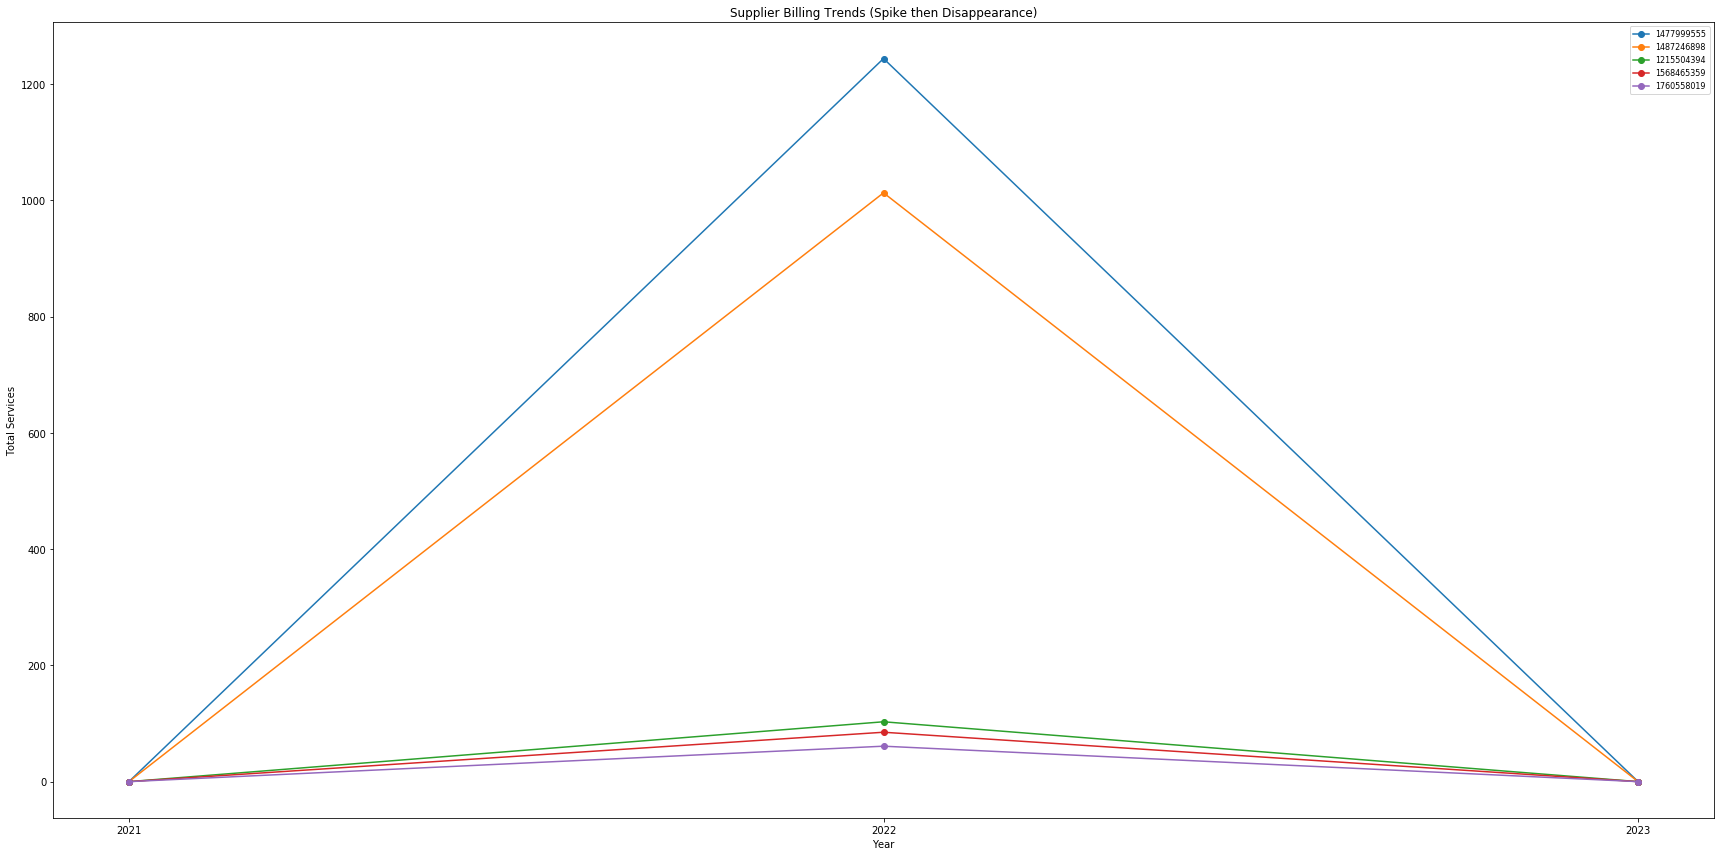

In [17]:
# Top suppliers used in the visualization
top_suppliers = fraud_pattern.head()

# NPIs for the line plot
top_npis = top_suppliers.index.tolist()

# Convert pivot table back to long format for line plot
trend_df = pivot.loc[top_npis].reset_index().melt(
    id_vars="suplr_npi",
    value_vars=[2021, 2022, 2023],
    var_name="year",
    value_name="tot_suplr_srvcs"
)

fig, axes = plt.subplots(1, figsize=(24, 12))

# -------------------------
# LINE PLOT (Supplier Trend)
# -------------------------
for npi in top_npis:

    data = trend_df[trend_df["suplr_npi"] == npi]

    axes.plot(
        data["year"],
        data["tot_suplr_srvcs"],
        marker="o",
        label=str(npi)
    )

axes.set_xticks([2021, 2022, 2023])
axes.set_title("Supplier Billing Trends (Spike then Disappearance)")
axes.set_xlabel("Year")
axes.set_ylabel("Total Services")
axes.legend(fontsize=8)


plt.tight_layout()
plt.show()

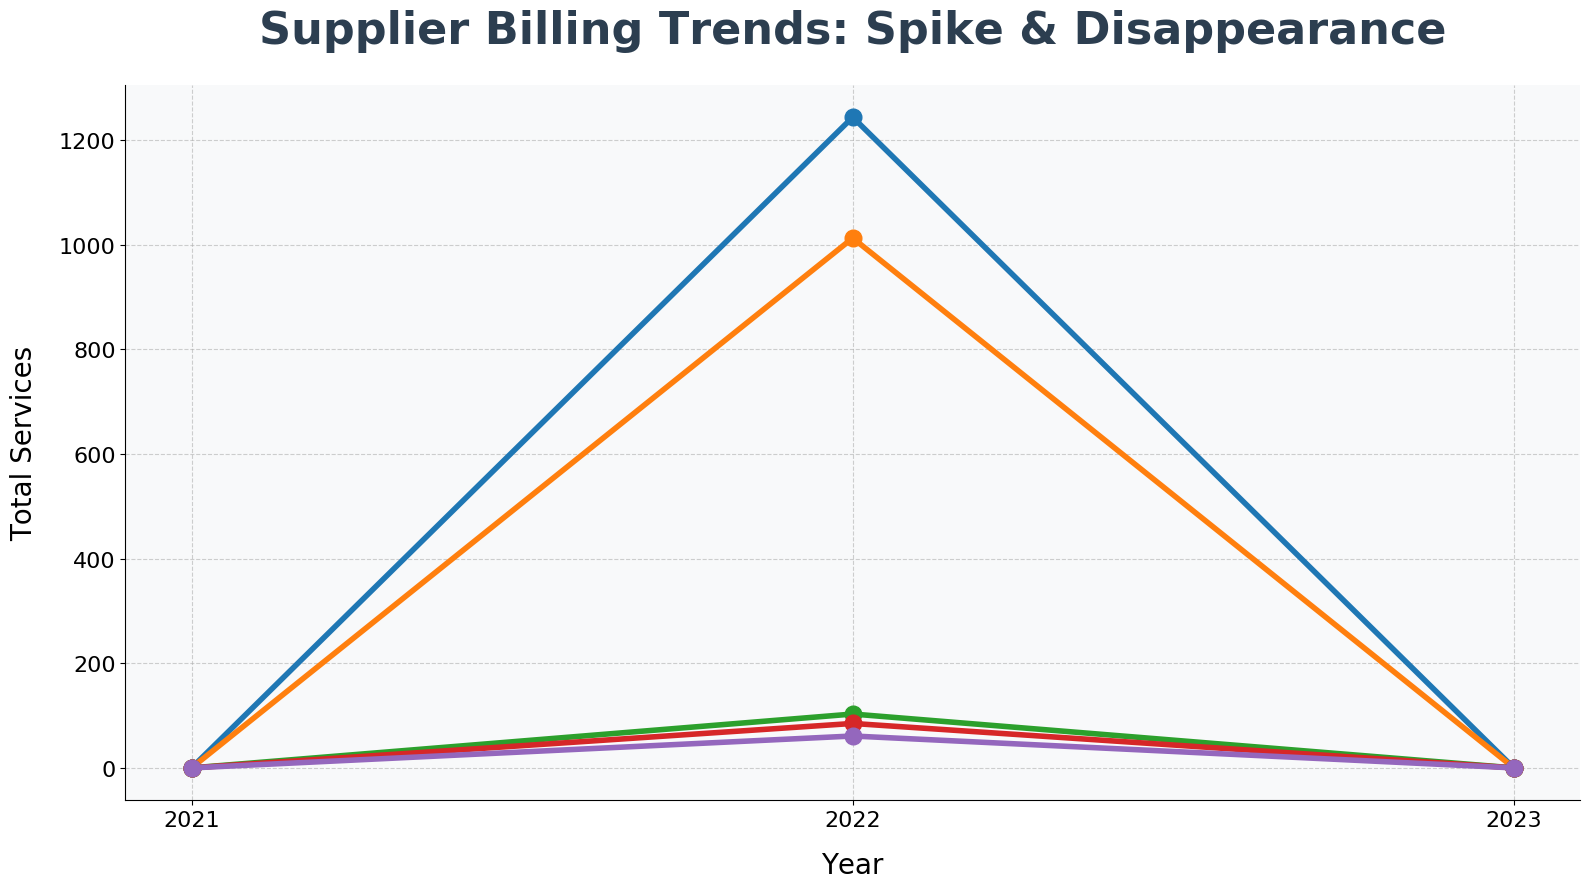

In [18]:
# Increase DPI for a crisp presentation image
fig, ax = plt.subplots(figsize=(16, 9), dpi=100)

# Set a clean background style
ax.set_facecolor('#f8f9fa')
ax.grid(True, linestyle='--', alpha=0.6, zorder=0)

for npi in top_npis:
    data = trend_df[trend_df["suplr_npi"] == npi]
    
    ax.plot(
        data["year"],
        data["tot_suplr_srvcs"],
        marker="o",
        markersize=12,    # Larger points
        linewidth=4,      # Thicker lines
        label=str(npi),
        zorder=3
    )

# --- VISUAL ENHANCEMENTS ---

# Huge Title for presentations
ax.set_title("Supplier Billing Trends: Spike & Disappearance", 
             fontsize=32, pad=30, fontweight='bold', color='#2c3e50')

# Clearer Axis Labels
ax.set_xlabel("Year", fontsize=20, labelpad=15)
ax.set_ylabel("Total Services", fontsize=20, labelpad=15)

# Larger Tick Labels
ax.set_xticks([2021, 2022, 2023])
ax.tick_params(axis='both', labelsize=16)

# Legend refinement
# ax.legend(title="Supplier NPI", title_fontsize=16, fontsize=14, 
#           loc='upper right', frameon=True, shadow=True)

# Remove top/right spines for a modern look
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

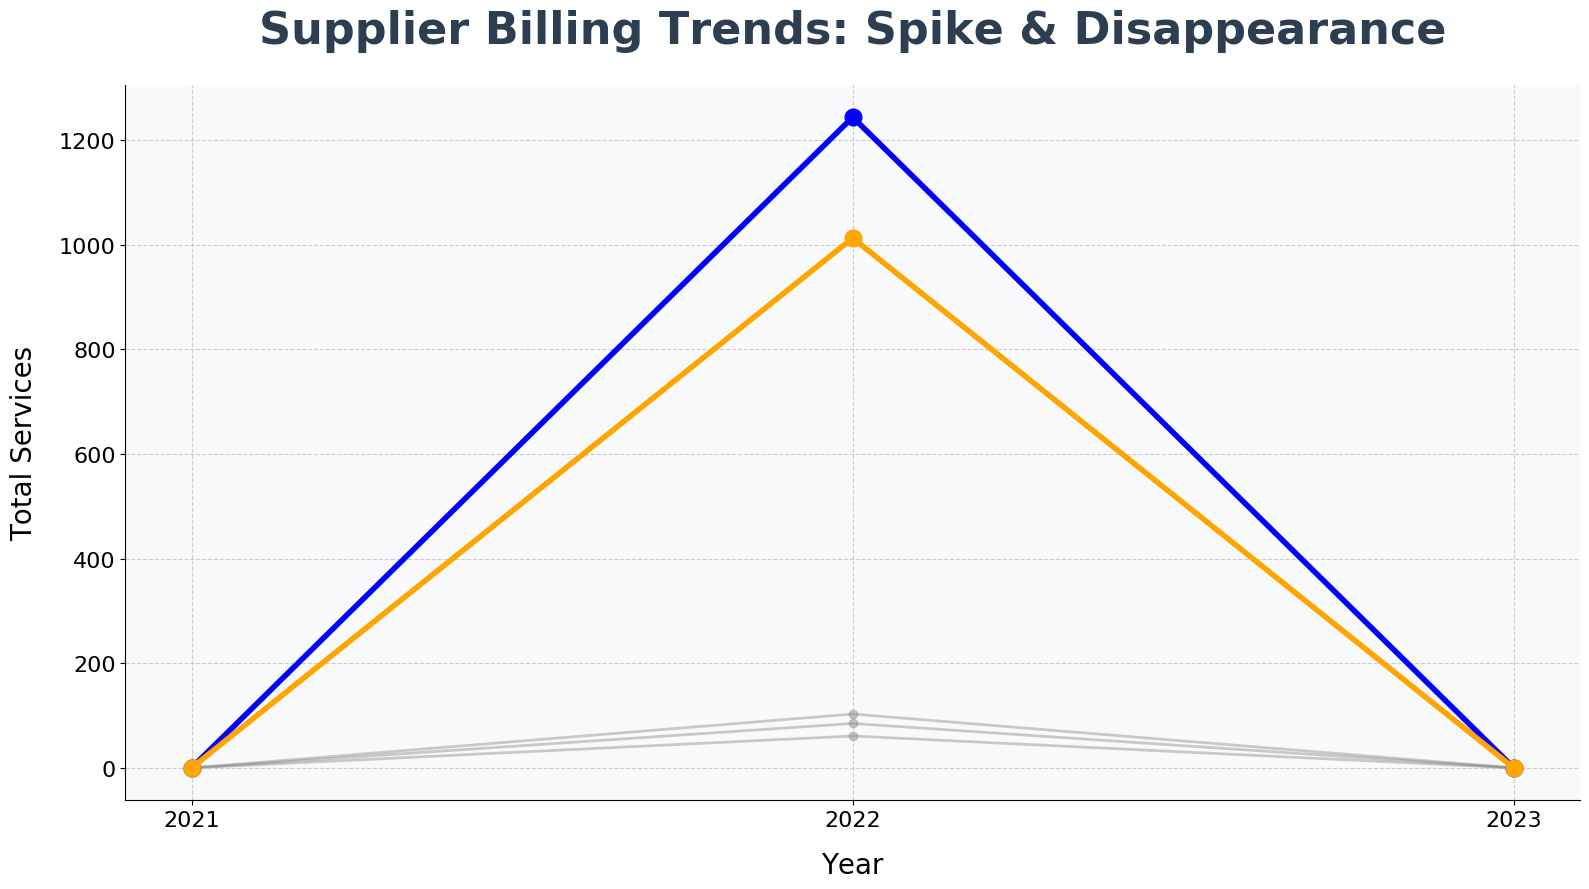

In [19]:
# Increase DPI for a crisp presentation image
fig, ax = plt.subplots(figsize=(16, 9), dpi=100)

# Set a clean background style
ax.set_facecolor('#f8f9fa')
ax.grid(True, linestyle='--', alpha=0.6, zorder=0)

# Define top 2 NPIs
top_2 = top_npis[:2]
others = top_npis[2:]

# --- Plot OTHER suppliers in grey (background) ---
for npi in others:
    data = trend_df[trend_df["suplr_npi"] == npi]
    
    ax.plot(
        data["year"],
        data["tot_suplr_srvcs"],
        color='grey',
        alpha=0.4,
        linewidth=2,
        marker='o',
        markersize=6,
        zorder=1
    )

# --- Plot TOP 2 suppliers in blue & orange (foreground) ---
colors = ['blue', 'orange']

for i, npi in enumerate(top_2):
    data = trend_df[trend_df["suplr_npi"] == npi]
    
    ax.plot(
        data["year"],
        data["tot_suplr_srvcs"],
        color=colors[i],
        marker="o",
        markersize=12,
        linewidth=4,
        label=f"Top {i+1}: {npi}",
        zorder=3
    )

# --- VISUAL ENHANCEMENTS ---

ax.set_title("Supplier Billing Trends: Spike & Disappearance", 
             fontsize=32, pad=30, fontweight='bold', color='#2c3e50')

ax.set_xlabel("Year", fontsize=20, labelpad=15)
ax.set_ylabel("Total Services", fontsize=20, labelpad=15)

ax.set_xticks([2021, 2022, 2023])
ax.tick_params(axis='both', labelsize=16)

# # Legend ONLY for top 2
# ax.legend(title="Highlighted Suppliers", title_fontsize=16, fontsize=14,
#           loc='upper right', frameon=True, shadow=True)

# Remove top/right spines
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

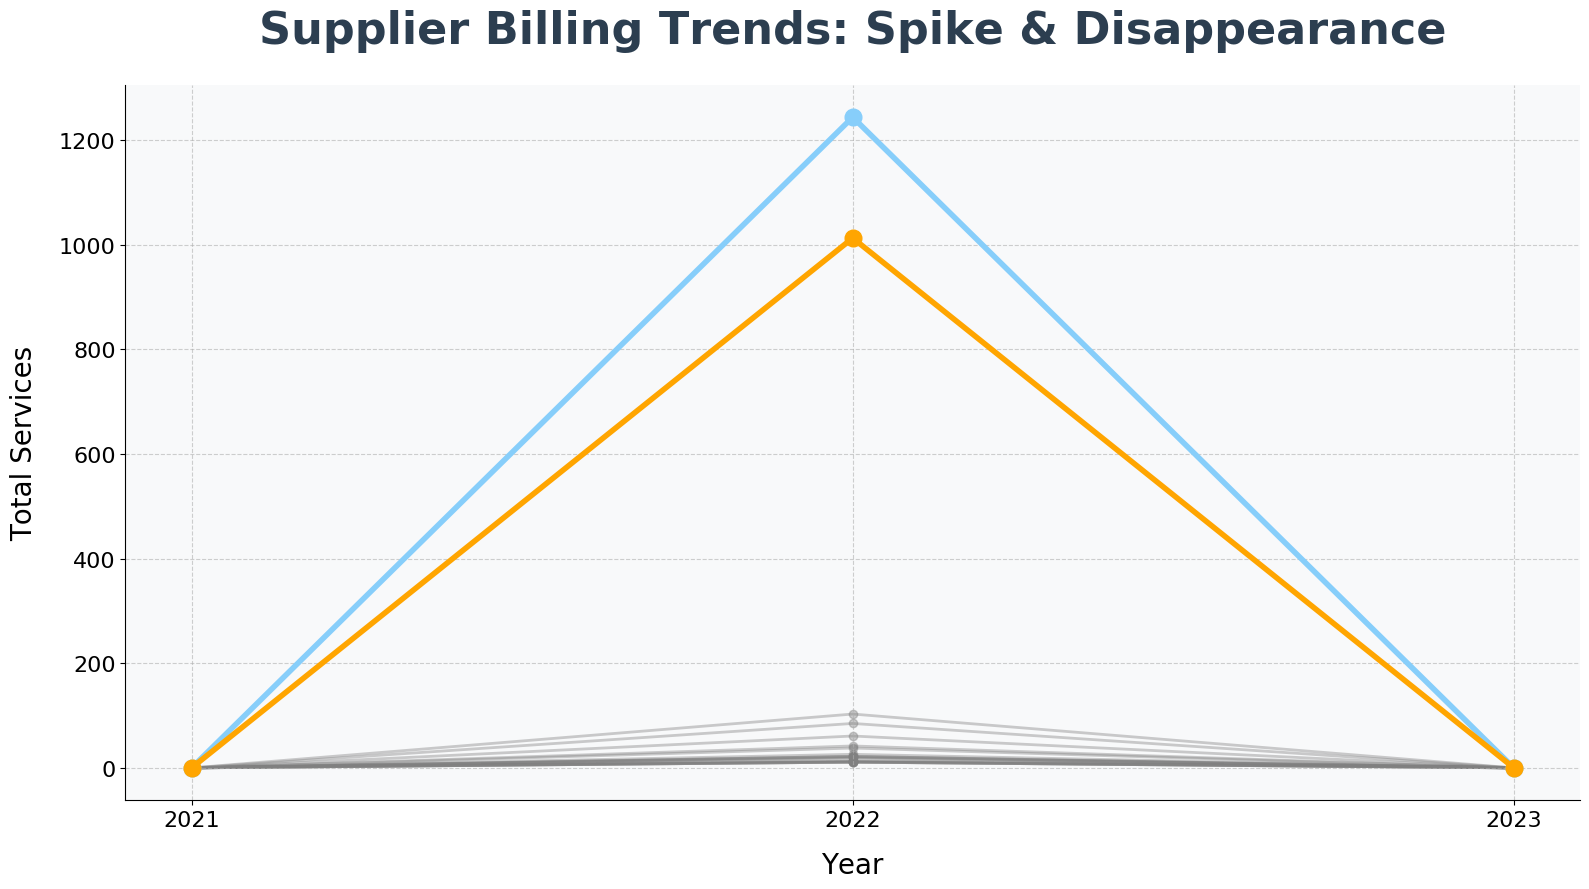

In [20]:
# NPIs for the line plot
all_npis = all_pattern.index.tolist()

# Convert pivot table back to long format for line plot
all_trend_df = pivot.loc[all_npis].reset_index().melt(
    id_vars="suplr_npi",
    value_vars=[2021, 2022, 2023],
    var_name="year",
    value_name="tot_suplr_srvcs"
)

# Increase DPI for a crisp presentation image
fig, ax = plt.subplots(figsize=(16, 9), dpi=100)

# Set a clean background style
ax.set_facecolor('#f8f9fa')
ax.grid(True, linestyle='--', alpha=0.6, zorder=0)

# Define top 2 NPIs
top_2 = all_npis[:2]
others = all_npis[2:]

# --- Plot OTHER suppliers in grey (background) ---
for npi in others:
    data = all_trend_df[all_trend_df["suplr_npi"] == npi]
    
    ax.plot(
        data["year"],
        data["tot_suplr_srvcs"],
        color='grey',
        alpha=0.4,
        linewidth=2,
        marker='o',
        markersize=6,
        zorder=1
    )

# --- Plot TOP 2 suppliers in blue & orange (foreground) ---
colors = ['#87CEFA', 'orange']

for i, npi in enumerate(top_2):
    data = trend_df[trend_df["suplr_npi"] == npi]
    
    ax.plot(
        data["year"],
        data["tot_suplr_srvcs"],
        color=colors[i],
        marker="o",
        markersize=12,
        linewidth=4,
        label=f"Top {i+1}: {npi}",
        zorder=3
    )

# --- VISUAL ENHANCEMENTS ---

ax.set_title("Supplier Billing Trends: Spike & Disappearance", 
             fontsize=32, pad=30, fontweight='bold', color='#2c3e50')

ax.set_xlabel("Year", fontsize=20, labelpad=15)
ax.set_ylabel("Total Services", fontsize=20, labelpad=15)

ax.set_xticks([2021, 2022, 2023])
ax.tick_params(axis='both', labelsize=16)

# # Legend ONLY for top 2
# ax.legend(title="Highlighted Suppliers", title_fontsize=16, fontsize=14,
#           loc='upper right', frameon=True, shadow=True)

# Remove top/right spines
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

In [21]:
trend_df

,suplr_npi,year,tot_suplr_srvcs
0,1477999555,2021,0.0
1,1487246898,2021,0.0
2,1215504394,2021,0.0
3,1568465359,2021,0.0
4,1760558019,2021,0.0
5,1477999555,2022,1244.0
6,1487246898,2022,1013.0
7,1215504394,2022,103.0
8,1568465359,2022,85.0
9,1760558019,2022,61.0


In [22]:
all_npis

[1477999555,
 1487246898,
 1215504394,
 1568465359,
 1760558019,
 1841226420,
 1306918305,
 1932135514,
 1083206486,
 1316278013,
 1528503133,
 1407929417,
 1962767061,
 1629214572,
 1194116061,
 1619173846,
 1457377848,
 1801850490,
 1316072986,
 1235732603]

In [23]:
# -----------------------------------------
# EXPORT DATA FOR LINE PLOT (TREND)
# -----------------------------------------

# Use the top suppliers already identified
top_suppliers = fraud_pattern.sort_values(
    "growth_21_22", ascending=False
).head(5)

top_npis = top_suppliers.index.tolist()

# Convert pivot to long format
trend_export = pivot.loc[top_npis].reset_index().melt(
    id_vars="suplr_npi",
    value_vars=[2021, 2022, 2023],
    var_name="year",
    value_name="tot_suplr_srvcs"
)

trend_export.to_csv("supplier_spike_trend.csv", index=False)

print("Saved: supplier_spike_trend.csv")

Saved: supplier_spike_trend.csv


In [24]:
trend_export

,suplr_npi,year,tot_suplr_srvcs
0,1477999555,2021,0.0
1,1487246898,2021,0.0
2,1215504394,2021,0.0
3,1568465359,2021,0.0
4,1760558019,2021,0.0
5,1477999555,2022,1244.0
6,1487246898,2022,1013.0
7,1215504394,2022,103.0
8,1568465359,2022,85.0
9,1760558019,2022,61.0


In [25]:
# -----------------------------------------
# EXPORT HCPCS TABLE FOR SUPPLIERS
# -----------------------------------------

# Filter original dataset for those suppliers
supplier_hcpcs_code = df_mo[df_mo["suplr_npi"].isin(top_npis)]

# Sum services by supplier and HCPCS code
supplier_hcpcs_code = (
    supplier_hcpcs_code
    .groupby(["suplr_npi","hcpcs_cd"])["tot_suplr_srvcs"]
    .sum()
    .reset_index()
)

# Pivot into table format
hcpcs_table = supplier_hcpcs_code.pivot(
    index="suplr_npi",
    columns="hcpcs_cd",
    values="tot_suplr_srvcs"
).fillna(0)

# Keep only columns with activity
hcpcs_table = hcpcs_table.loc[:, (hcpcs_table.sum() > 0)]

hcpcs_table.to_csv("supplier_hcPCS_table.csv")

print("Saved: supplier_hcPCS_table.csv")

Saved: supplier_hcPCS_table.csv


In [26]:
supplier_hcpcs = supplier_hcpcs.reset_index(drop=True)
supplier_hcpcs

,suplr_npi,suplr_prvdr_last_name_org,hcpcs_cd,hcpcs_desc,tot_suplr_srvcs
0,1215504394,Top Medical Center Lp,L1832,"Knee orthosis, adjustable knee joints (unicentric or polycentric), positional orthosis, rigid support, prefabricated item that has been trimmed, bent, molded, assembled, or otherwise customized to fit a specific patient by an individual with expertise",25
1,1215504394,Top Medical Center Lp,L1833,"Knee orthosis, adjustable knee joints (unicentric or polycentric), positional orthosis, rigid support, prefabricated, off-the shelf",23
2,1215504394,Top Medical Center Lp,L1851,"Knee orthosis (ko), single upright, thigh and calf, with adjustable flexion and extension joint (unicentric or polycentric), medial-lateral and rotation control, with or without varus/valgus adjustment, prefabricated, off-the-shelf",14
3,1215504394,Top Medical Center Lp,L2397,"Addition to lower extremity orthosis, suspension sleeve",41
4,1477999555,Evans Drugs Sunrise Beach Llc,J7620,"Albuterol, up to 2.5 mg and ipratropium bromide, up to 0.5 mg, fda-approved final product, non-compounded, administered through dme",1230
5,1477999555,Evans Drugs Sunrise Beach Llc,Q0513,Pharmacy dispensing fee for inhalation drug(s); per 30 days,14
6,1487246898,Mercy Pharmacy Services Llc,A4253,"Blood glucose test or reagent strips for home blood glucose monitor, per 50 strips",23
7,1487246898,Mercy Pharmacy Services Llc,J7507,"Tacrolimus, immediate release, oral, 1 mg",990
8,1568465359,Nizam,V2020,"Frames, purchases",17
9,1568465359,Nizam,V2200,"Sphere, bifocal, plano to plus or minus 4.00d, per lens",35


In [27]:
supplier_hcpcs.to_csv("surges_products.csv")
print("Saved: surges_products.csv")

Saved: surges_products.csv


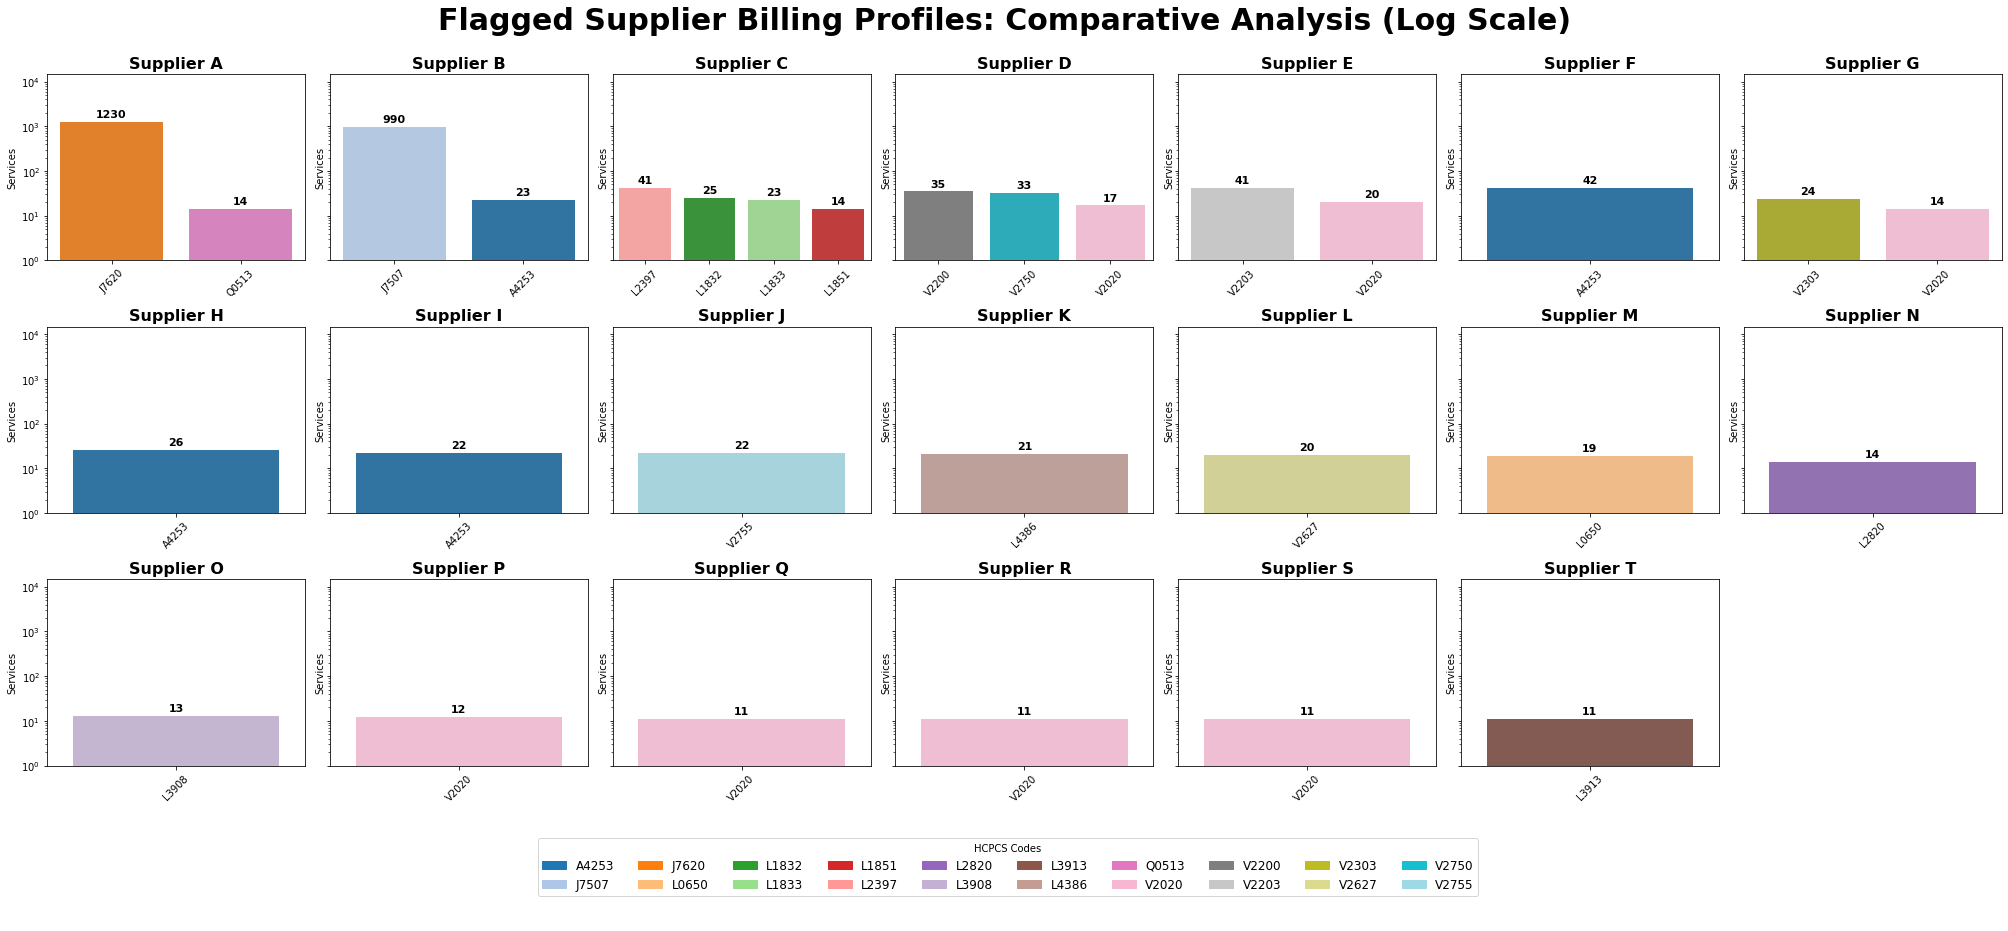

In [28]:
import seaborn as sns
import math
import string
import matplotlib.patches as mpatches

# 1. Setup Data & Colors
all_npis = all_pattern.index.tolist()
plot_data = df_mo[(df_mo["suplr_npi"].isin(all_npis)) & (df_mo["year"] == 2022) & (df_mo["tot_suplr_srvcs"] > 0)].copy()

unique_codes = sorted(plot_data['hcpcs_cd'].unique())
palette_colors = sns.color_palette("tab20", len(unique_codes))
code_color_map = dict(zip(unique_codes, palette_colors))

# 2. RECTANGULAR GRID SETUP
num_npis = len(all_npis)
cols = 7  # Increased columns for a landscape "Rectangle" shape
rows = math.ceil(num_npis / cols)

# Adjusting figsize: Wide (28) and relatively shorter height (4 per row)
fig, axes = plt.subplots(rows, cols, figsize=(28, 4.5 * rows), sharey=True) 
axes = axes.flatten()

# 3. LOOP
for i, npi in enumerate(all_npis):
    npi_specific_data = plot_data[plot_data["suplr_npi"] == npi].sort_values("tot_suplr_srvcs", ascending=False)
    
    if not npi_specific_data.empty:
        sns.barplot(
            data=npi_specific_data, 
            x="hcpcs_cd", y="tot_suplr_srvcs", 
            ax=axes[i], hue="hcpcs_cd",
            palette=code_color_map, dodge=False
        )
        
        # Manual legend removal for older Seaborn versions
        leg = axes[i].get_legend()
        if leg: leg.remove()
        
        axes[i].set_yscale('log')
        
        # Bar Labels
        for p in axes[i].patches:
            height = p.get_height()
            if height > 0:
                axes[i].text(p.get_x() + p.get_width() / 2., height * 1.15, 
                             f'{int(height)}', ha='center', va='bottom', 
                             fontsize=11, fontweight='bold') # Slightly smaller font for tighter grid
        
        # Titles
        supplier_label = string.ascii_uppercase[i] if i < 26 else f"Z{i-25}"
        axes[i].set_title(f"Supplier {supplier_label}", fontweight='bold', fontsize=16)
        
        # Cleanup
        axes[i].set_xlabel("") 
        axes[i].set_ylabel("Services")
        axes[i].tick_params(axis='x', rotation=45, labelsize=10)
        axes[i].set_ylim(1, plot_data["tot_suplr_srvcs"].max() * 12)
        
    else:
        axes[i].axis('off') 

# Remove extra empty subplots if any
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

# 4. GLOBAL LEGEND
legend_handles = [mpatches.Patch(color=color, label=code) for code, color in code_color_map.items()]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.03), 
    ncol=min(len(legend_handles), 10), # More columns in legend to match wide plot
    title="HCPCS Codes",
    fontsize=12,
    frameon=True
)

# 5. POLISH
# Higher 'rect' bottom value (0.15) to ensure the legend doesn't overlap the bottom row
plt.tight_layout(rect=[0, 0.15, 1, 0.94]) 

fig.suptitle('Flagged Supplier Billing Profiles: Comparative Analysis (Log Scale)', 
             fontsize=30, y=0.98, fontweight='bold')

plt.show()

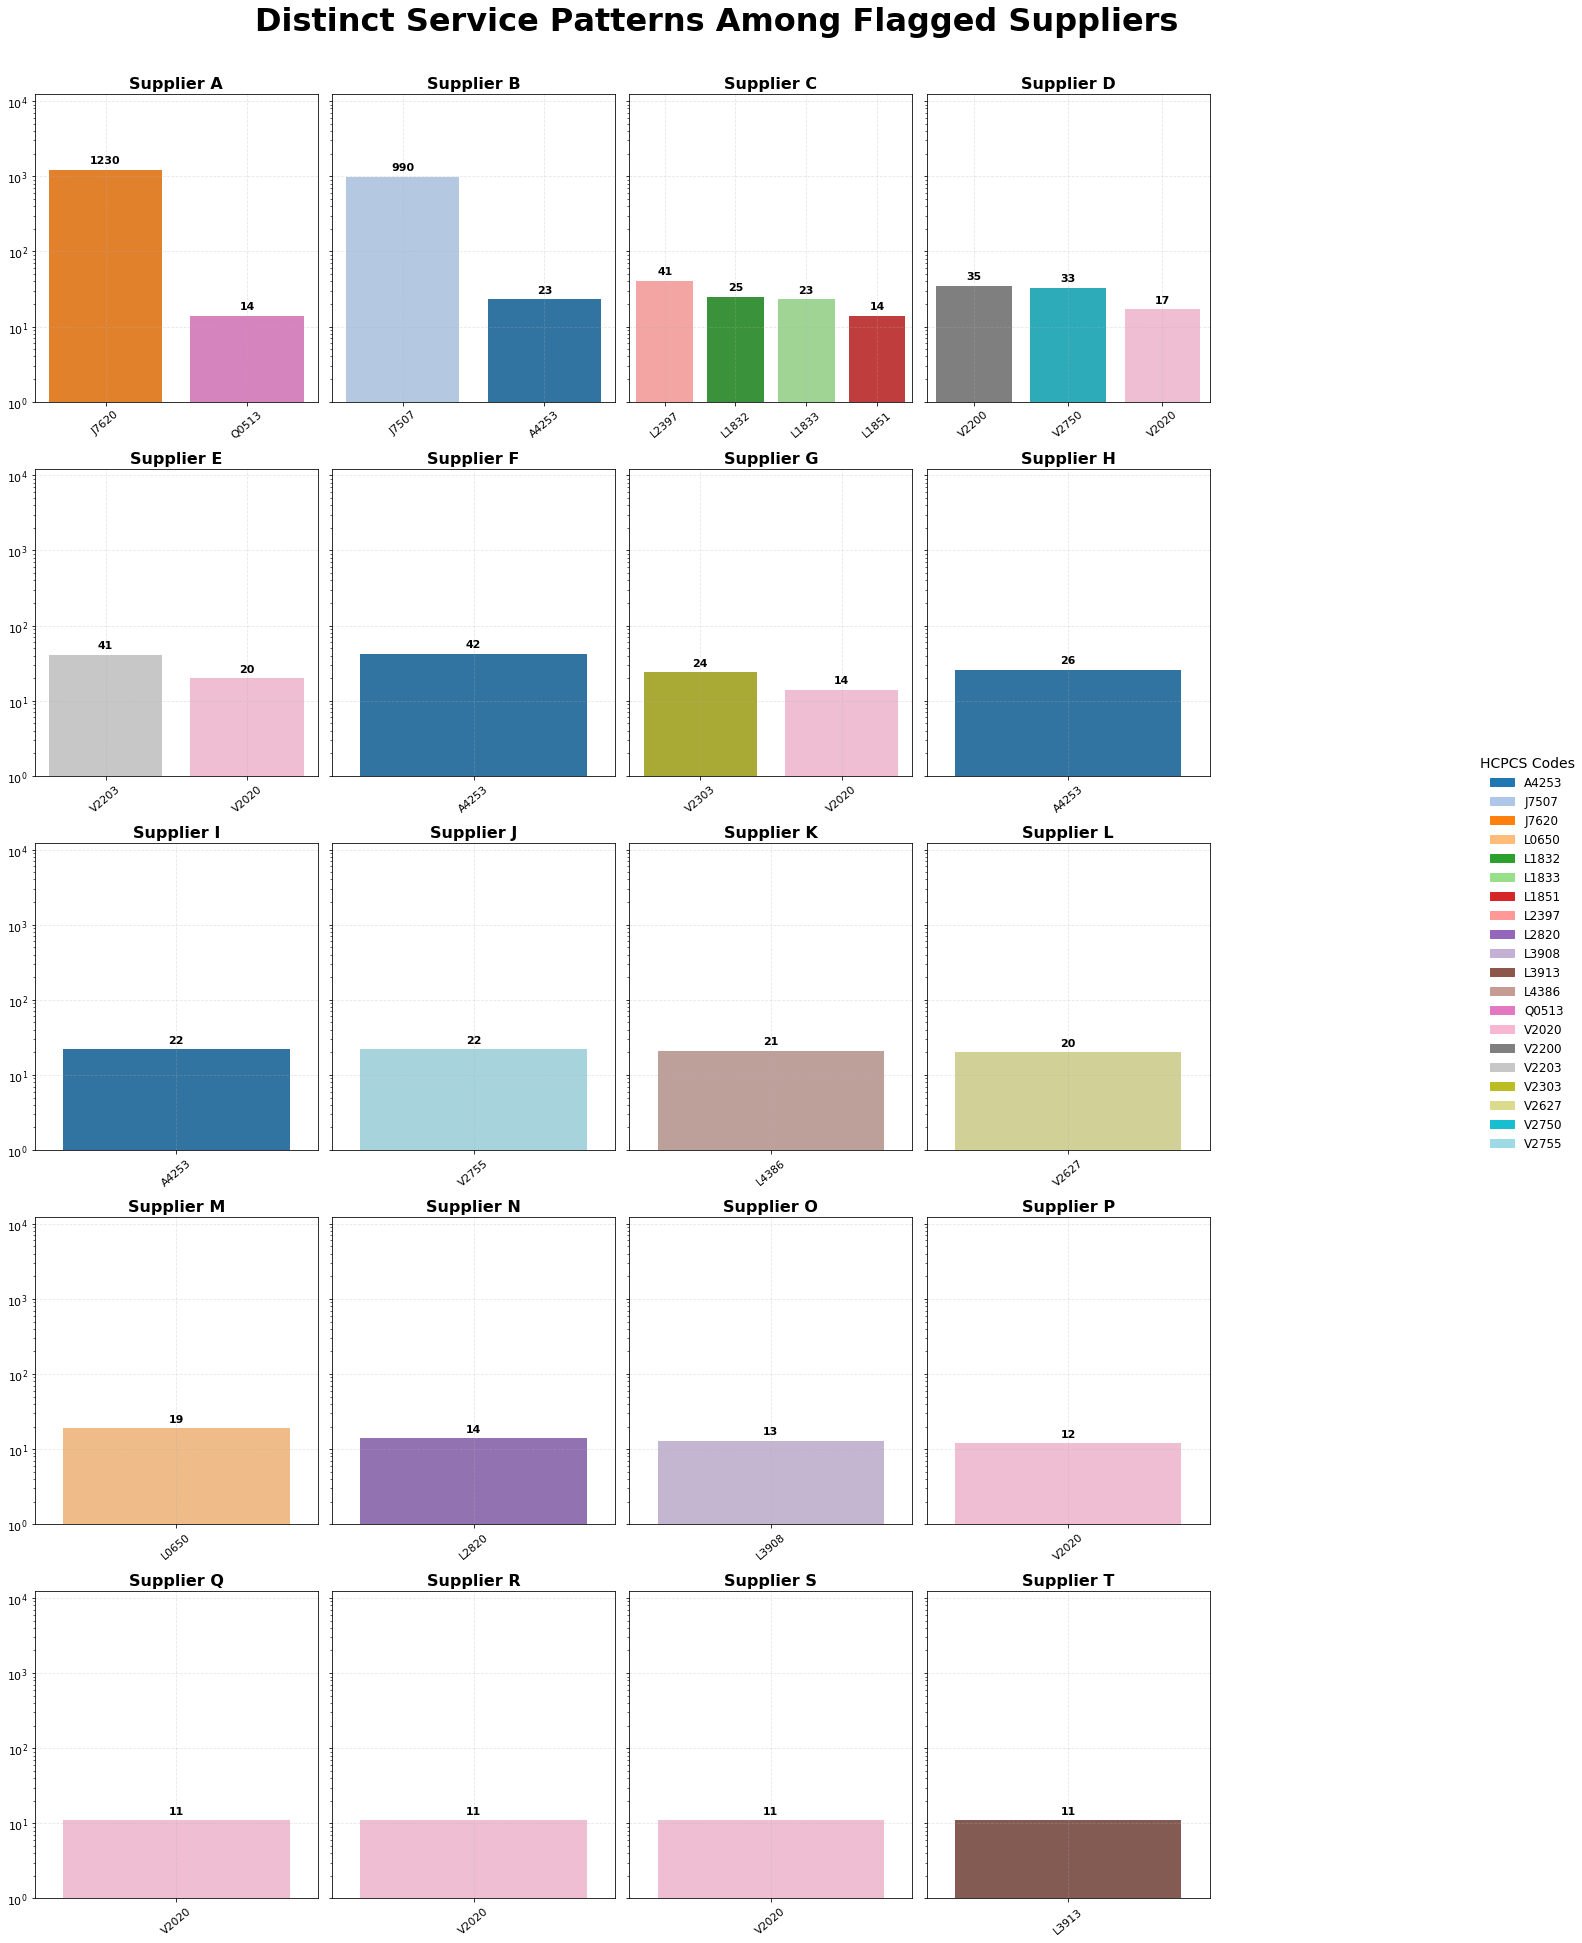

In [29]:
# ---------------------------
# DATA SETUP
# ---------------------------
all_npis = all_pattern.index.tolist()

plot_data = df_mo[
    (df_mo["suplr_npi"].isin(all_npis)) &
    (df_mo["year"] == 2022) &
    (df_mo["tot_suplr_srvcs"] > 0)
].copy()

# Color mapping
unique_codes = sorted(plot_data['hcpcs_cd'].unique())
palette_colors = sns.color_palette("tab20", len(unique_codes))
code_color_map = dict(zip(unique_codes, palette_colors))

# ---------------------------
# GRID (LESS COLUMNS = BIGGER CHARTS)
# ---------------------------
cols = 4   # 🔥 THIS FIXES READABILITY
rows = math.ceil(len(all_npis) / cols)

fig, axes = plt.subplots(
    rows, cols,
    figsize=(20, 5.5 * rows),   # taller plots
    sharey=True
)
axes = axes.flatten()

# ---------------------------
# LOOP
# ---------------------------
for i, npi in enumerate(all_npis):

    npi_data = plot_data[
        plot_data["suplr_npi"] == npi
    ].sort_values("tot_suplr_srvcs", ascending=False)

    if not npi_data.empty:

        # Limit bars (still important)
        npi_data = npi_data.head(4)

        sns.barplot(
            data=npi_data,
            x="hcpcs_cd",
            y="tot_suplr_srvcs",
            ax=axes[i],
            hue="hcpcs_cd",
            palette=code_color_map,
            dodge=False
        )

        # Remove subplot legends
        leg = axes[i].get_legend()
        if leg:
            leg.remove()

        # Log scale
        axes[i].set_yscale('log')

        # Labels on bars
        for p in axes[i].patches:
            height = p.get_height()
            if height > 10:
                axes[i].text(
                    p.get_x() + p.get_width() / 2.,
                    height * 1.15,
                    f'{int(height)}',
                    ha='center',
                    va='bottom',
                    fontsize=11,
                    fontweight='bold'
                )

        # Titles
        label = string.ascii_uppercase[i] if i < 26 else f"S{i}"
        axes[i].set_title(
            f"Supplier {label}",
            fontsize=16,
            fontweight='bold'
        )

        # 🔥 BIGGER AXIS TEXT
        axes[i].tick_params(axis='x', rotation=40, labelsize=11)
        axes[i].tick_params(axis='y', labelsize=11)

        axes[i].set_xlabel("")
        axes[i].set_ylabel("")

        axes[i].grid(True, linestyle='--', alpha=0.3)

        axes[i].set_ylim(1, plot_data["tot_suplr_srvcs"].max() * 10)

    else:
        axes[i].axis('off')

# Remove empty plots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

# ---------------------------
# 🔥 LEGEND ON THE RIGHT (VISIBLE!)
# ---------------------------
legend_handles = [
    mpatches.Patch(color=color, label=code)
    for code, color in code_color_map.items()
]

fig.legend(
    handles=legend_handles,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),  # right side
    title="HCPCS Codes",
    fontsize=12,
    title_fontsize=14,
    frameon=False
)

# ---------------------------
# FINAL POLISH
# ---------------------------
plt.tight_layout(rect=[0, 0, 0.85, 0.95])  # leave space for legend

fig.suptitle(
    "Distinct Service Patterns Among Flagged Suppliers",
    fontsize=32,
    fontweight='bold'
)
 # ---------------------------
# SAVE FIGURE (HIGH QUALITY)
# ---------------------------
plt.savefig(
    "supplier_service_patterns.png",
    dpi=300,                # 🔥 high resolution for PPT
    bbox_inches='tight',    # removes extra whitespace
    facecolor='white'       # clean background
)

plt.show()

In [30]:
#To check the ones, that where saved, you checked the .csv files that where created